# plotting results

FFDI results


In [74]:
import intake
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np

from glob import glob
import pathlib
import traceback
from datetime import datetime



In [75]:
from dask.distributed import Client
import dask

# Set configuration options
dask.config.set({
    'distributed.comm.timeouts.connect': '90s',  # Timeout for connecting to a worker
    'distributed.comm.timeouts.tcp': '90s',  # Timeout for TCP communications
})

#cluster = LocalCluster(
#    n_workers=28,          # Number of workers
#    threads_per_worker=1 #Threads per worker
#    #memory_limit='8GB' # Memory limit per each worker commented out
#)
#client = Client(cluster)

client = Client()
client

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33781 instead
  warnings.warn(


Modifying workers


/g/data/hh5/public/apps/dask-optimiser/schedplugin.py:160: UserWarning: Attempted illegal binding: []
  warn(f"Attempted illegal binding: {(sorted(list(self.slots_available - taken_slots))[:self.worker.state.nthreads])}")
/g/data/hh5/public/apps/dask-optimiser/schedplugin.py:160: UserWarning: Attempted illegal binding: []
  warn(f"Attempted illegal binding: {(sorted(list(self.slots_available - taken_slots))[:self.worker.state.nthreads])}")
/g/data/hh5/public/apps/dask-optimiser/schedplugin.py:160: UserWarning: Attempted illegal binding: []
  warn(f"Attempted illegal binding: {(sorted(list(self.slots_available - taken_slots))[:self.worker.state.nthreads])}")
/g/data/hh5/public/apps/dask-optimiser/schedplugin.py:160: UserWarning: Attempted illegal binding: []
  warn(f"Attempted illegal binding: {(sorted(list(self.slots_available - taken_slots))[:self.worker.state.nthreads])}")
/g/data/hh5/public/apps/dask-optimiser/schedplugin.py:160: UserWarning: Attempted illegal binding: []
  warn(f"A

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /node/gadi-cpu-bdw-0034.gadi.nci.org.au/10269/proxy/33781/status,
Dashboard: /node/gadi-cpu-bdw-0034.gadi.nci.org.au/10269/proxy/33781/status,Workers: 14
Total threads: 14,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35033,Workers: 14
Dashboard: /node/gadi-cpu-bdw-0034.gadi.nci.org.au/10269/proxy/33781/status,Total threads: 14
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42009,Total threads: 1
Dashboard: /node/gadi-cpu-bdw-0034.gadi.nci.org.au/10269/proxy/34473/status,Memory: 0 B
Nanny: tcp://127.0.0.1:38783,


In [125]:
# parameters
dirstore='sa_2050'

In [126]:
#
dirsave='/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/'
outf1='/scratch/xv83/rxm599/'+dirstore+'/*_[5]_ffdi_t.zarr'
outf2='/scratch/xv83/rxm599/'+dirstore+'/*_ffdi_ex.nc'
print(outf2)
ds1 = xr.open_mfdataset(outf1, engine='zarr',
    combine="nested",   # treat files as ordered sequence
    concat_dim="model",  # new dimension name
    #drop_variables=["FFDI_t"],
)
ds2 = xr.open_mfdataset(outf2, 
    combine="nested",   # treat files as ordered sequence
    concat_dim="model"  # new dimension name
)
ds2

/scratch/xv83/rxm599/sa_2050/*_ffdi_ex.nc


<xarray.Dataset>
Dimensions:        (lat: 691, lon: 886, model: 22, season: 4)
Coordinates:
  * lat            (lat) float64 -44.5 -44.45 -44.4 ... -10.1 -10.05 -10.0
  * lon            (lon) float64 112.0 112.0 112.1 112.2 ... 156.2 156.2 156.2
    quantile       float64 0.95
    region         int64 0
    abbrevs        <U3 'AUS'
    names          <U9 'Australia'
  * season         (season) <U3 'DJF' 'JJA' 'MAM' 'SON'
Dimensions without coordinates: model
Data variables:
    FFDI_mean      (model, lat, lon) float64 dask.array<chunksize=(1, 691, 886), meta=np.ndarray>
    tot_days       (model, lat, lon, season) float64 dask.array<chunksize=(1, 691, 886, 4), meta=np.ndarray>
    seasonal_clim  (model, lat, lon, season) float32 dask.array<chunksize=(1, 691, 886, 4), meta=np.ndarray>

In [127]:
FM=ds2.FFDI_mean.mean(dim='model')
FS=ds2.FFDI_mean.std(dim='model')
Rerr=FS/FM
Fdays=ds2.tot_days
Fmean=ds2.seasonal_clim

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/ffdi_extreme_sa_2050.png


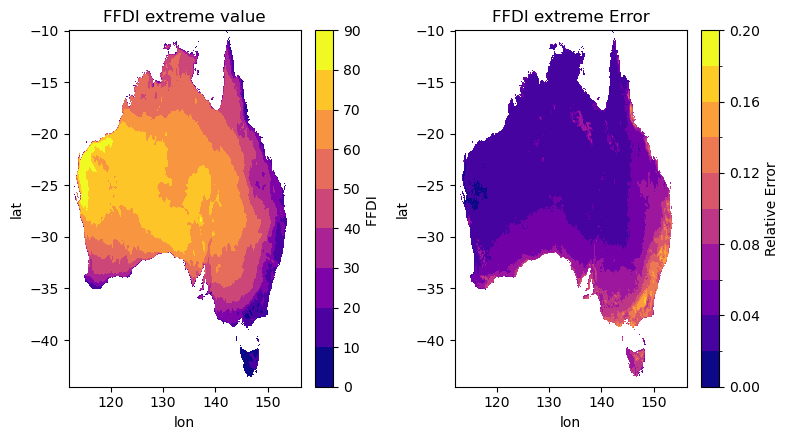

In [128]:
# plot FFDI extreme and relative error
plt.figure(figsize=(8,4.5))
plt.subplot(1,2,1)
ax=FM.plot(cmap='plasma',levels=10)
colorbar=ax.colorbar
ax=plt.title('FFDI extreme value')
colorbar.set_label('FFDI ')            

mask = Rerr > 0.2
ax=plt.contourf(mask.lon, mask.lat, mask, levels=[0.5, 1.5], colors='none',
            hatches=['...', ' '], alpha=0.4 )
# Change hatch color to white
for collection in ax.collections[-2:]:
    collection.set_edgecolor("white")
    collection.set_facecolor("none")   # ensure no fill covers your plot
    collection.set_linewidth(1.0)

plt.subplot(1,2,2)
ax=Rerr.plot(cmap='plasma',levels=10)
colorbar=ax.colorbar
ax=plt.title('FFDI extreme Error')
colorbar.set_label('Relative Error')
ax=plt.tight_layout()


fname=dirsave+'ffdi_extreme_'+dirstore+'.png'
print(fname)
plt.savefig(fname, dpi=150, bbox_inches="tight")

In [129]:
%%time
# variables storing seasonal number of days and mean values
# filter data based on relative error from multiple simulations
def filter(F):
    SM = F.mean(dim='model')
    SE = F.std(dim='model')
    RE = SE/(SM+1e-1)
    SF= SM.where(RE < .5)
    return SM,SF,RE

Sdays,SFdays,Rdays= filter(Fdays)
Smean,SFmean,Rmean= filter(Fmean)


CPU times: user 55.3 ms, sys: 783 µs, total: 56.1 ms
Wall time: 51.9 ms


In [130]:
# plotting the index that is maximum

def plot_max_index(SM1,ndim,tit,fname='tmp.png'):
    pmax = SM1.fillna(-np.inf).argmax(dim=ndim)
# Set max_index to NaN where all values were NaN
    all_nan_mask = SM1.isnull().all(dim=ndim)
    pmax = pmax.where(~all_nan_mask)
    nvar=SM1[ndim].values
    lp1=len(nvar)+1
    ax=pmax.plot(cmap="tab10",levels=np.arange(lp1)-.5)
# Replace ticks with variable names
    nvar=SM1[ndim].values
    colorbar = ax.colorbar
    ticks = np.arange(len(nvar))  # 0,1,2,3
    colorbar.set_ticks(ticks)
    colorbar.set_ticklabels(nvar)
    colorbar.set_label('Season')
    ax=plt.title(tit)
    ax=plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    

In [131]:
def plot_4(SM1,RE,ndim,id,lev,tit,fname='tmp.png'):
    cb='plasma'
    mask = RE > 0.25

    plt.figure(figsize=(8,8))
    plt.subplot(2,2,1); SM1.sel(season=id[0]).plot(levels=lev,cmap=cb,extend='max')
#    plt.contourf(RE.lon, RE.lat, mask.sel(season=id[0]), levels=[0.5, 1.5], colors='none',
#            hatches=['', '///'], alpha=.2)
#ax=plt.contourf(mask.lon, mask.lat, mask, levels=[0.5, 1.5], colors='none',
#            hatches=['...', ' '], alpha=0.4 )
# Change hatch color to white
#for collection in ax.collections[-2:]:
#    collection.set_edgecolor("white")
#    collection.set_facecolor("none")   # ensure no fill covers your plot
#    collection.set_linewidth(1.0)

    plt.title(id[0])
    
    plt.subplot(2,2,2); SM1.sel(season=id[1]).plot(levels=lev,cmap=cb,extend='max')
    plt.title(id[1])
    plt.subplot(2,2,3); SM1.sel(season=id[2]).plot(levels=lev,cmap=cb,extend='max')
    plt.title(id[2])
    plt.subplot(2,2,4); SM1.sel(season=id[3]).plot(levels=lev,cmap=cb,extend='max')
    plt.title(id[3])
# Add global title
    plt.suptitle(tit)
# Adjust layout so titles don’t overlap
    plt.tight_layout()

    plt.savefig(fname, dpi=150, bbox_inches="tight")
    return

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/season_extreme_sa_2050.png


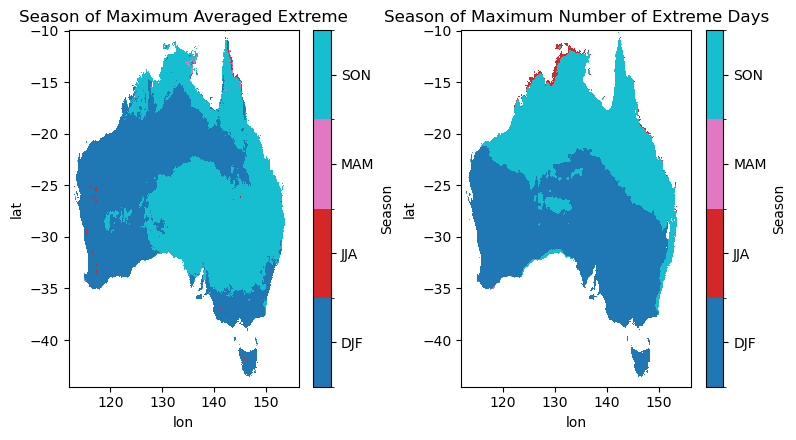

In [132]:
# Season with extremes
plt.figure(figsize=(8,4.5))
# Compute Index with the largest value
SM2= SFmean  #.sel(stat=1)
nvar=SM2.season.values
ndim='season'
tit='Season of Maximum Averaged Extreme'
plt.subplot(1,2,1)
plot_max_index(SM2,ndim,tit)

# Compute Index with the largest value
SM2=SFdays   #.sel(stat=1)
nvar=SM2.season.values
ndim='season'
tit='Season of Maximum Number of Extreme Days'
plt.subplot(1,2,2)
plot_max_index(SM2,ndim,tit)
fname=dirsave+'season_extreme_'+dirstore+'.png'
print(fname)
plt.savefig(fname, dpi=150, bbox_inches="tight")

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/season_days_sa_2050.png
['DJF' 'JJA' 'MAM' 'SON']


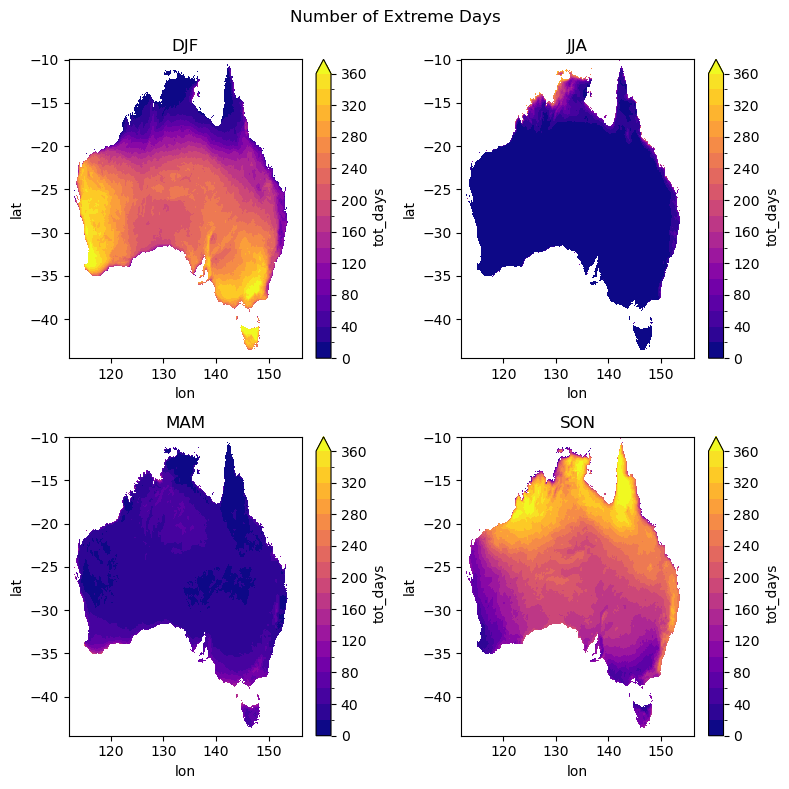

In [133]:
SM2=SFdays
SM2=Sdays
nvar=SM2.season.values
fname=dirsave+'season_days_'+dirstore+'.png'
lev = np.linspace(0, 360, 19)
titl='Number of Extreme Days'
print(fname)
print(nvar)
plot_4(SM2,Rdays,'season',nvar,lev, titl, fname)

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/season_days_err_sa_2050.png
['DJF' 'JJA' 'MAM' 'SON']


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


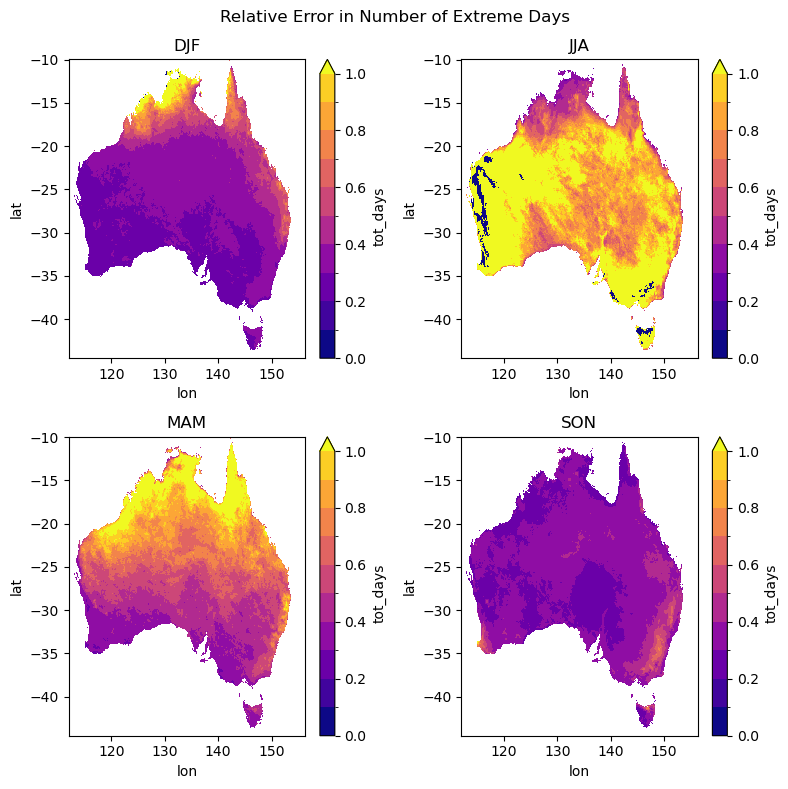

In [134]:
SM2=Sdays
SM2=Rdays
#SM2 = Rdays> 0.2
nvar=SM2.season.values
fname=dirsave+'season_days_err_'+dirstore+'.png'
lev = np.linspace(0, 1, 11)
titl='Relative Error in Number of Extreme Days'
print(fname)
print(nvar)
plot_4(SM2,SM2,'season',nvar,lev,titl, fname)